In [5]:
import geopandas as gpd
import rasterio
import numpy as np
import rasterio.mask
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from shapely import wkt

In [6]:
df = pd.read_csv('datos/grid_data_2001_2013.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)

In [7]:
df = gpd.GeoDataFrame(df, geometry='geometry')
df['x'] = df.geometry.centroid.x
df['y'] = df.geometry.centroid.y

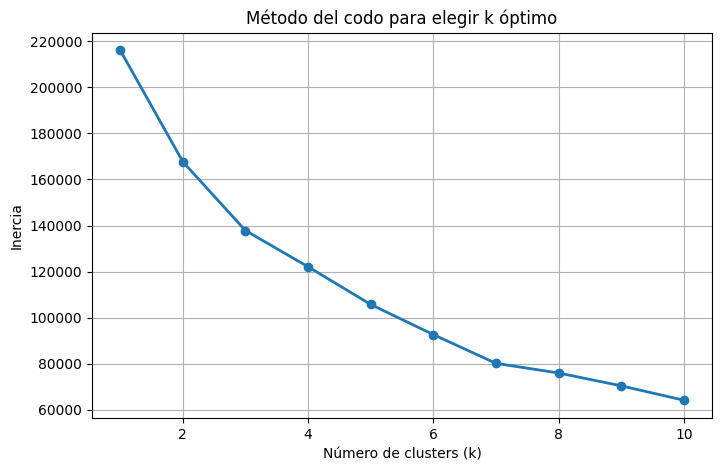

In [8]:

def metodo_del_codo(gdf, columnas_variables, max_clusters=10):
    """
    Aplica el método del codo para encontrar el número óptimo de clusters.
    
    Parámetros:
    - gdf: GeoDataFrame con tus datos
    - columnas_variables: lista de columnas a usar para clustering (deben ser numéricas)
    - max_clusters: número máximo de clusters a evaluar
    
    Retorna:
    - Lista de inercias para cada k
    """
    
    # Preparar los datos
    X = gdf[columnas_variables].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    inercias = []
    K_range = range(1, max_clusters + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inercias.append(kmeans.inertia_)

    # Graficar el codo
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inercias, 'o-', linewidth=2)
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia')
    plt.title('Método del codo para elegir k óptimo')
    plt.grid(True)
    plt.show()

    return inercias
variables = ['ndvi', 'lst', 'presencia_lobos','nlcd', 'x', 'y']  # Asegúrate de tener 'x', 'y' en el GeoDataFrame
inercias = metodo_del_codo(df, columnas_variables=variables, max_clusters=10)


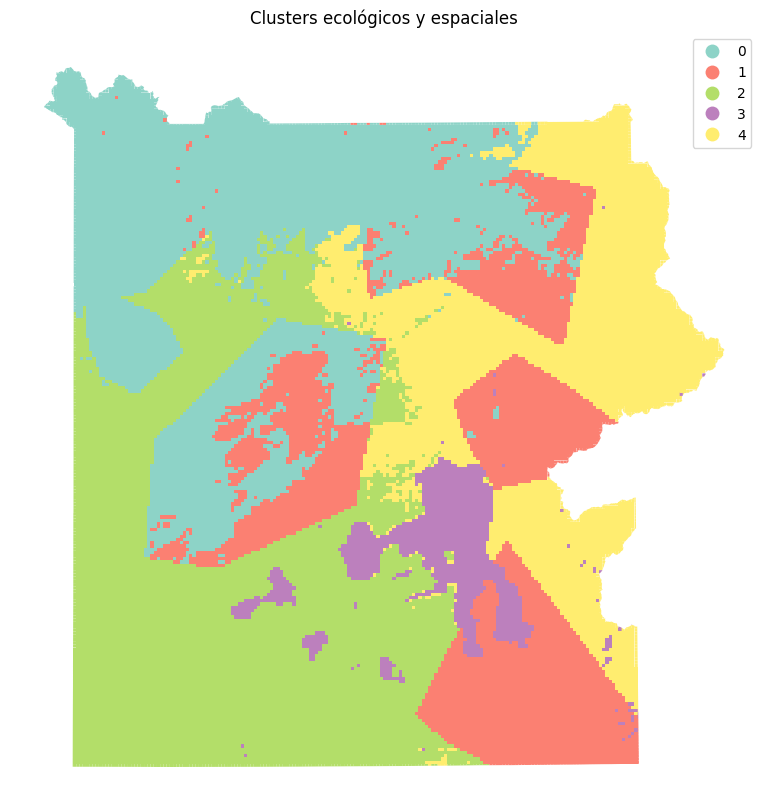

In [11]:
X = df[variables].copy()
# 4. Escalar todo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Aplicar KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Suponiendo que tu GeoDataFrame ya tiene la columna 'cluster'
fig, ax = plt.subplots(figsize=(10, 10))

df.plot(column='cluster', ax=ax, categorical=True, legend=True, cmap='Set3', markersize=2)

ax.set_title('Clusters ecológicos y espaciales')
ax.axis('off')
plt.show()


/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_42588/3708160757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_42588/3708160757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_42588/3708160757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q

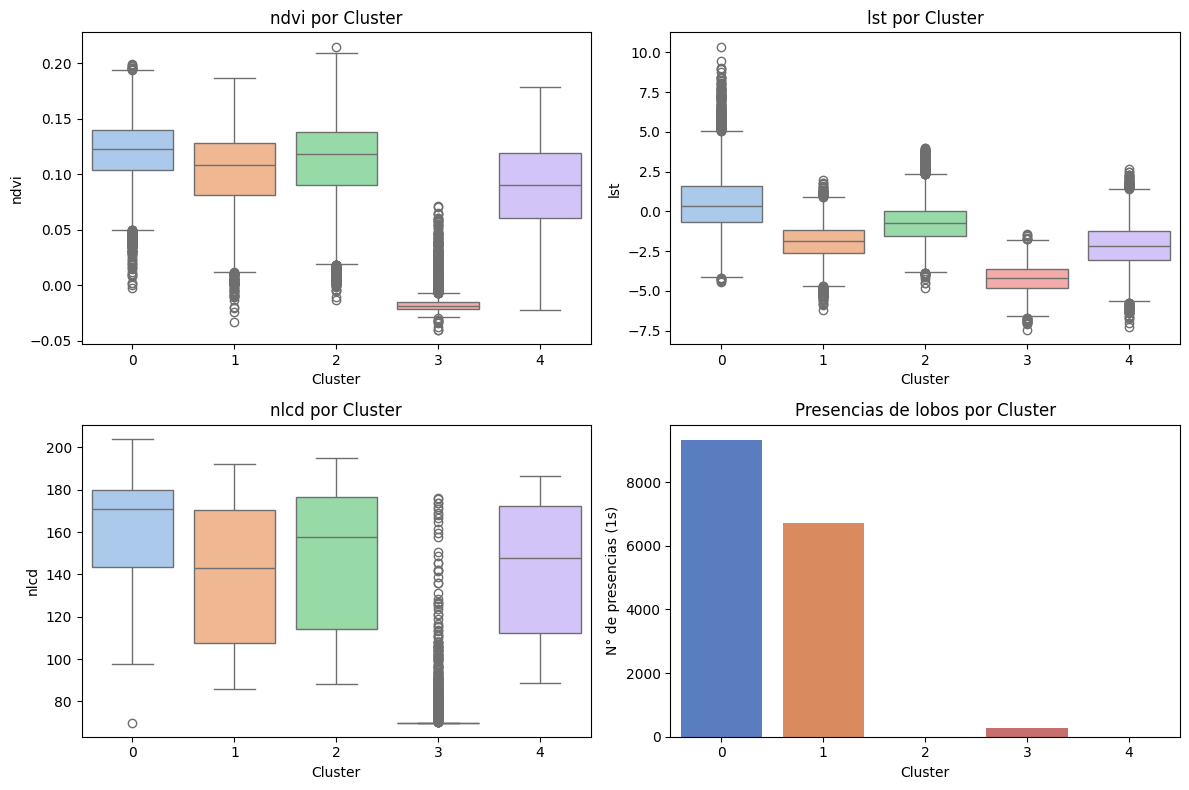

In [12]:
# Lista de variables para boxplot (excluimos 'presencia_lobos')
features_box = ['ndvi', 'lst','nlcd']
n_cols = 2
n_rows = (len(features_box) + 1 + n_cols - 1) // n_cols  # +1 por gráfico de barras

plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Boxplots de variables continuas
for i, var in enumerate(features_box):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
    plt.title(f"{var} por Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(var)

# Gráfico de barras para presencias de lobos
plt.subplot(n_rows, n_cols, len(features_box) + 1)

# Calcular número de presencias (1s) por cluster
lobos_por_cluster = df.groupby('cluster')['presencia_lobos'].sum().reset_index()
sns.barplot(x="cluster", y="presencia_lobos", data=lobos_por_cluster, palette="muted")

plt.title("Presencias de lobos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("N° de presencias (1s)")

plt.tight_layout()
plt.show()


# Para 2014-2024

In [13]:
df = pd.read_csv('datos/grid_data_2014_2024.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)
df = gpd.GeoDataFrame(df, geometry='geometry')
df['x'] = df.geometry.centroid.x
df['y'] = df.geometry.centroid.y

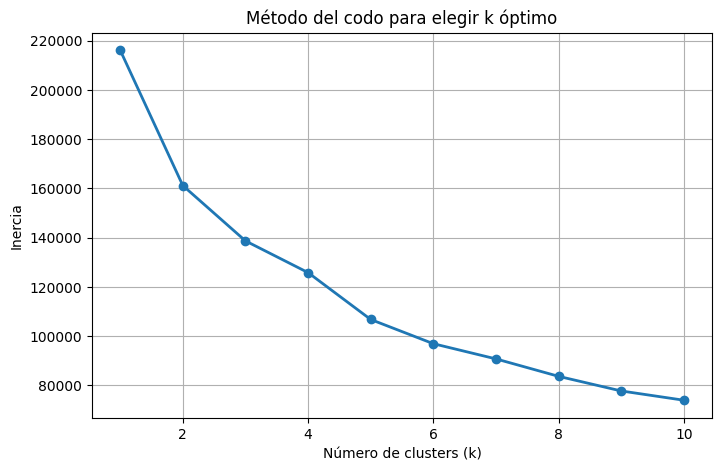

In [14]:
inercias = metodo_del_codo(df, columnas_variables=variables, max_clusters=10)


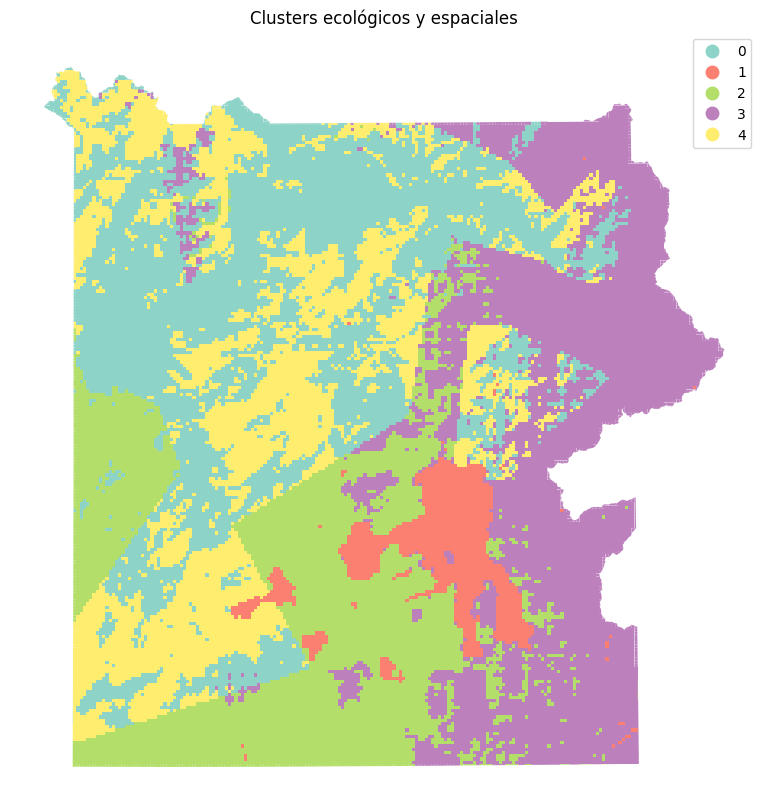

In [15]:
X = df[variables].copy()
# 4. Escalar todo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Aplicar KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Suponiendo que tu GeoDataFrame ya tiene la columna 'cluster'
fig, ax = plt.subplots(figsize=(10, 10))

df.plot(column='cluster', ax=ax, categorical=True, legend=True, cmap='Set3', markersize=2)

ax.set_title('Clusters ecológicos y espaciales')
ax.axis('off')
plt.show()


https://www.usgs.gov/media/images/nlcd-land-cover-classification-legend

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_42588/3708160757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_42588/3708160757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_42588/3708160757.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
/var/folders/lx/01q

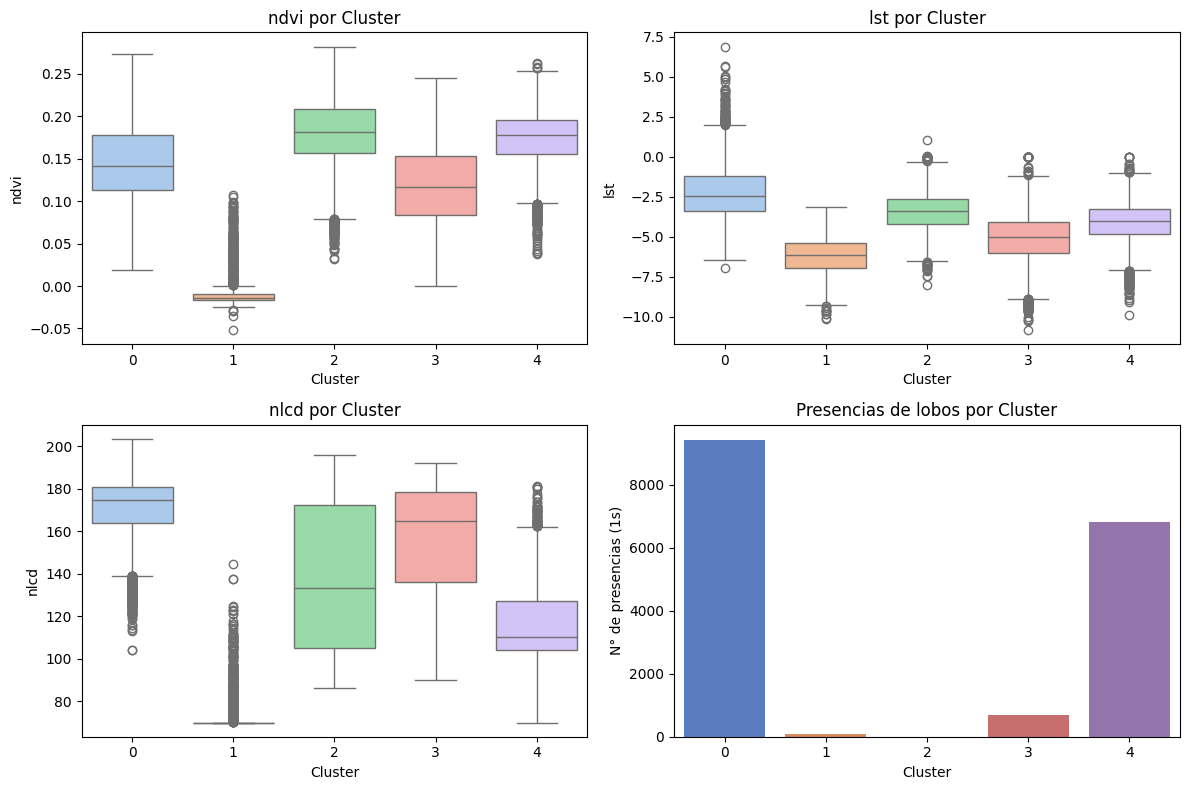

In [16]:
# Lista de variables para boxplot (excluimos 'presencia_lobos')
features_box = ['ndvi', 'lst','nlcd']
n_cols = 2
n_rows = (len(features_box) + 1 + n_cols - 1) // n_cols  # +1 por gráfico de barras

plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Boxplots de variables continuas
for i, var in enumerate(features_box):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x="cluster", y=var, data=df, palette="pastel")
    plt.title(f"{var} por Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(var)

# Gráfico de barras para presencias de lobos
plt.subplot(n_rows, n_cols, len(features_box) + 1)

# Calcular número de presencias (1s) por cluster
lobos_por_cluster = df.groupby('cluster')['presencia_lobos'].sum().reset_index()
sns.barplot(x="cluster", y="presencia_lobos", data=lobos_por_cluster, palette="muted")

plt.title("Presencias de lobos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("N° de presencias (1s)")

plt.tight_layout()
plt.show()


In [19]:
print(sorted(df['nlcd'].unique()))


[70.0, 70.419754, 70.47222, 70.53125, 70.94444, 71.0625, 71.208336, 71.25926, 71.359375, 71.416664, 71.541664, 71.59375, 71.679016, 71.68056, 71.93056, 72.03125, 72.125, 72.171875, 72.20988, 72.361115, 72.421875, 72.65625, 72.703125, 72.74074, 72.75, 72.93827, 72.958336, 73.013885, 73.083336, 73.171875, 73.1875, 73.30556, 73.34722, 73.46875, 73.625, 73.71875, 73.765625, 73.859375, 74.02778, 74.09375, 74.19753, 74.25, 74.375, 74.513885, 74.625, 74.72222, 74.78125, 74.921875, 75.203125, 75.3125, 75.53086, 76.138885, 76.19444, 76.40625, 76.46875, 76.611115, 76.61729, 76.75, 76.90625, 76.9375, 76.94444, 76.97222, 77.083336, 77.234375, 77.236115, 77.24691, 77.546875, 77.55556, 77.708336, 77.80556, 77.833336, 77.921875, 77.93056, 77.96875, 78.02778, 78.109375, 78.166664, 78.27778, 78.458336, 78.5, 78.52778, 78.671875, 78.96875, 79.03125, 79.05556, 79.25, 79.421875, 79.44444, 79.5625, 79.59259, 79.65278, 79.861115, 80.09375, 80.19444, 80.388885, 80.40625, 80.625, 80.80247, 80.81944, 80.84722,

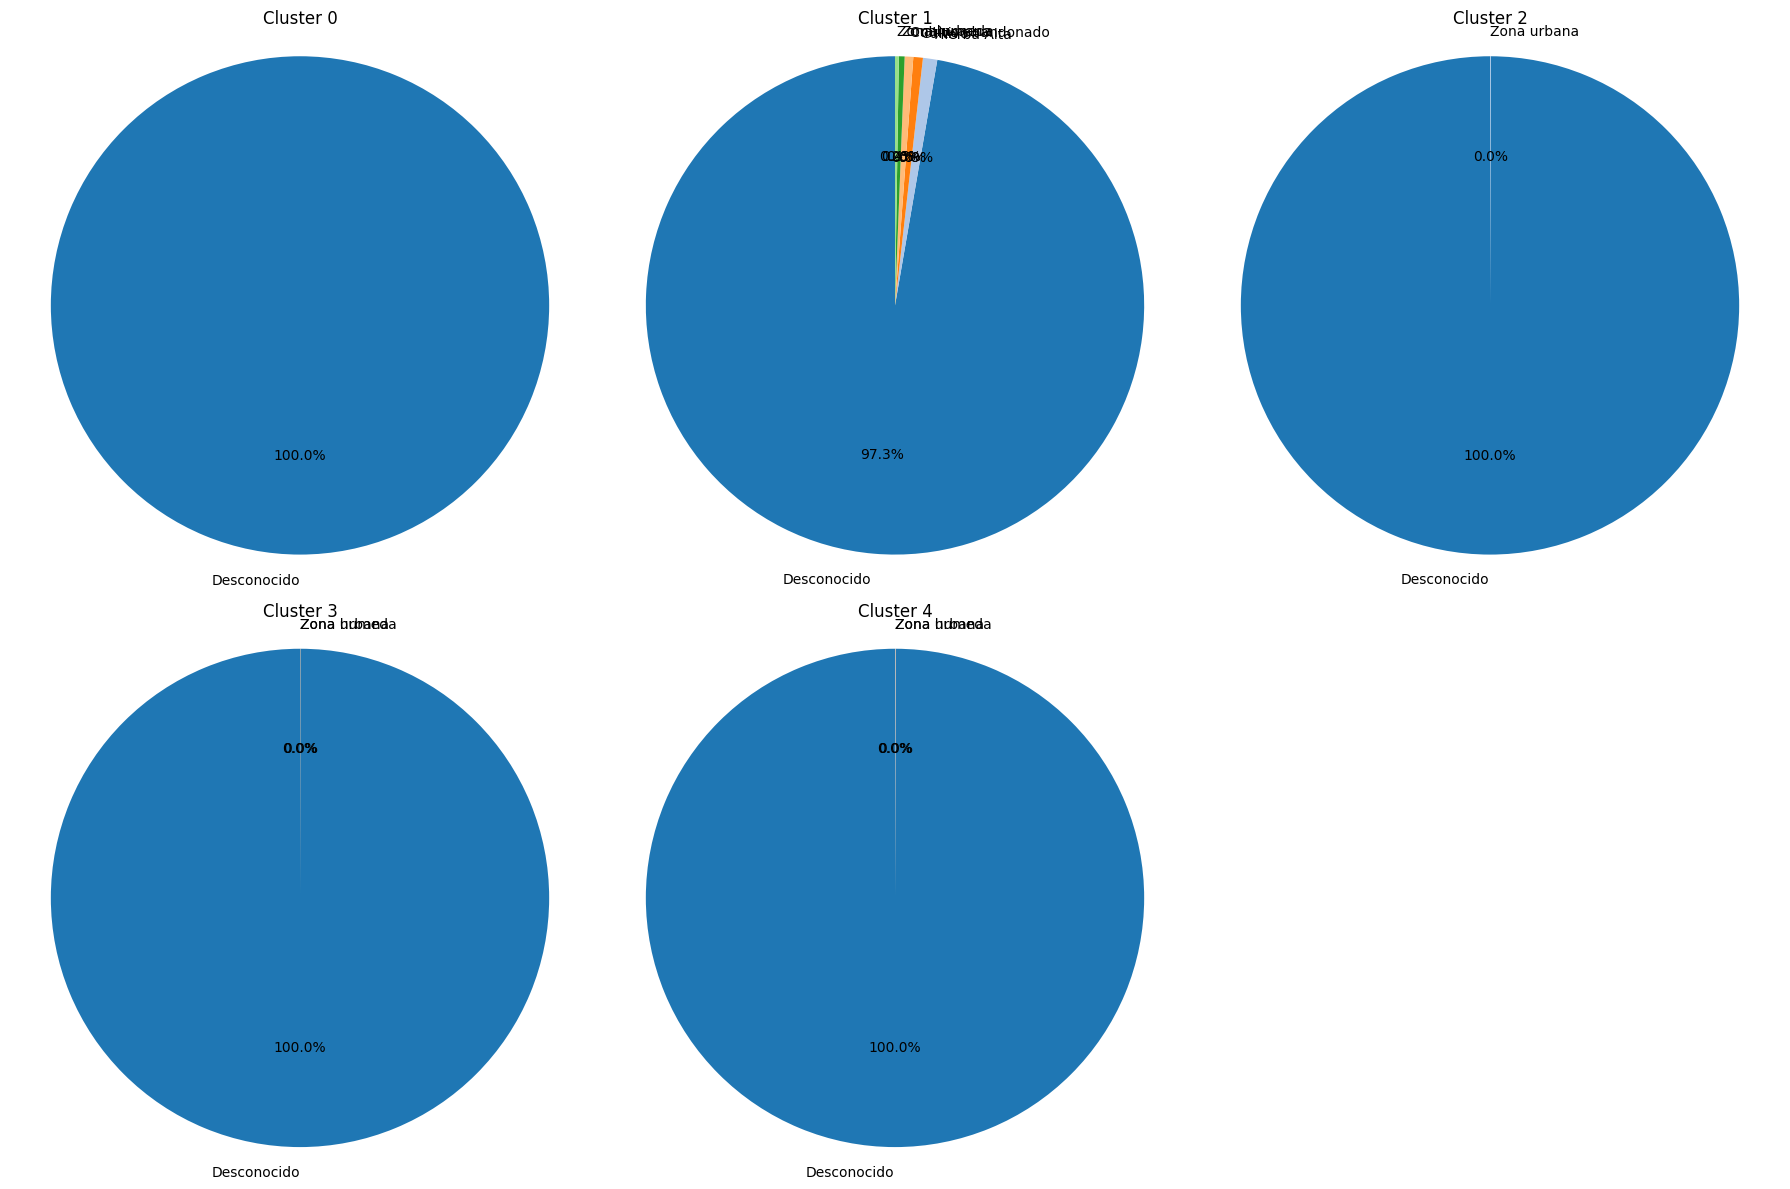

In [22]:
nlcd_dict = {
    11: 'Agua',
    21: 'Desierto/Rocas',
    22: 'Pastizales',
    23: 'Praderas',
    24: 'Pastos',
    31: 'Bares o suelo desnudo',
    41: 'Bosque Deciduo',
    42: 'Bosque Siempreverde',
    43: 'Bosque Mixto',
    52: 'Matorral',
    71: 'Hierba Alta',
    81: 'Cultivo',
    82: 'Cultivo abandonado',
    90: 'Zona humeda',
    95: 'Zona urbana',
}
df['nlcd_int'] = df['nlcd'].round().astype(int)
df['nlcd_cat'] = df['nlcd_int'].map(nlcd_dict).fillna('Desconocido')

# Lista de clusters únicos
clusters = sorted(df['cluster'].unique())

# Número de filas y columnas para los subplots (ajusta si tienes muchos clusters)
n_cols = 3
n_rows = (len(clusters) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 6))

for i, cluster in enumerate(clusters):
    plt.subplot(n_rows, n_cols, i + 1)
    subset = df[df['cluster'] == cluster]
    suelo_counts = subset['nlcd_cat'].value_counts()
    
    plt.pie(suelo_counts, labels=suelo_counts.index, autopct='%1.1f%%', startangle=90, 
            colors=plt.cm.tab20.colors)
    plt.title(f'Cluster {cluster}')
    plt.axis('equal')

plt.tight_layout()
plt.show()